## **IMPORTATION DES LIBRAIRIES**

In [ ]:
pip install metrics

In [ ]:
pip install scikit-plot

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import time

import nltk
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Activation,
    Dropout,
    Embedding,
    LSTM,
    SpatialDropout1D,
    InputLayer,
    Flatten,
    MaxPooling1D,
    Conv1D
)
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Scikit-learn
from sklearn.model_selection import (
    cross_val_score,
    StratifiedKFold,
    train_test_split
)
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
    LabelBinarizer,
    MultiLabelBinarizer
)
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    classification_report
)

# SciKeras - replacement for keras.wrappers.scikit_learn
from scikeras.wrappers import KerasClassifier

# NLTK
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from nltk.tokenize.treebank import TreebankWordDetokenizer

# Pandas
from pandas import read_csv
from pandas.plotting import scatter_matrix

# Matplotlib
from matplotlib import pyplot

## **IMPORTATION DU DATASET**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data-posts.csv to data-posts (2).csv


In [ ]:
pd.set_option('display.max_colwidth',100)
posts=pd.read_csv('data-posts.csv', encoding='utf-16', sep=';')

In [ ]:
posts['class']=posts['class'].replace("produits cosmétiques", "مستحضرات التجميل", regex=True)
posts['class']=posts['class'].replace("mode et vetement ", "الأزياء والملابس", regex=True)
posts['class']=posts['class'].replace("appareils électroniques", "أجهزة الكترونية", regex=True)
posts['class']=posts['class'].replace("articles de sport", "معدات الرياضية", regex=True)
posts['class']=posts['class'].replace("accessoires et bijoux", "اكسسوارات ومجوهرات", regex=True)
posts['class']=posts['class'].replace("matériel de couchage", " معدات نوم", regex=True)
posts['class']=posts['class'].replace("produits alimentaires", "مواد غذائية", regex=True)
posts['class']=posts['class'].replace("offre abonnement internet", "عرض اشتراك على الإنترنت", regex=True)
posts['class']=posts['class'].replace("outils de cuisine", "ادوات المطبخ", regex=True)
posts['class']=posts['class'].replace("appareils électriques", "الأجهزة الكهربائية", regex=True)
posts['class']=posts['class'].replace("robots de cuisine", "روبوتات المطبخ", regex=True)

In [ ]:
posts.head(11)

,facebook_posts,class
0,On n'a jamais assez de chaussures 👟 👠 👡 👢 \r\nاليوم كاين تخفيضات على الأحذية 😍 أبروفيتو !! \r\...,الأزياء والملابس
1,7abaa tkoun 3andek une peau rayonnante احسن المنتجات فالماركات لي تحبوهم L'Oréal و حتى Nivea Gar...,مستحضرات التجميل
2,ثاني واحد بعد ال @ رايح يشريلك Smart TV ماركيه فالكومنتير 😅😅\r\nوزيد قولو بلي كاين Flash Vente ه...,أجهزة الكترونية
3,Journée Spéciale Sport 😎🏃‍♀️ \r\nحاب تدير سبور فالدار 🏋️ و ما عندكش Matériel ؟ جوميا تعرض عليك أ...,معدات الرياضية
4,madame 3andek 3arss w 7aayra wesh diri accessoires??? اضربوا طلة على اختياراتنا في أروج المودي...,اكسسوارات ومجوهرات
5,kech plan more l3id ?? erwa7 dir bon plan camping m3a s7abek منتجات من وسائد وفراشات الخيام,معدات نوم
6,ماكاش أحلى من الشوكولاتة تهديها لحبايبك وعايلتك في أي وقت 🍫🤤 😍\r\nتقدروا تشوفوا كل العروض وتشرو...,مواد غذائية
7,connectez winma 7abit!! M3a Djezzy forfait internet yelha9 partout http://www.ooredoo.dz #Intern...,عرض اشتراك على الإنترنت
8,bedelte 3etba w 5assek t3amer darek !!! Rak f le bon endroit 😍 تقدروا تشوفوا كل العروض مطبخ فالم...,ادوات المطبخ
9,لكامل محبي L'électroménager Frigo lave-linge Télévision et ordinateur أبروفيتيو هاد السمانة 🔥 😍...,الأجهزة الكهربائية


In [ ]:
posts.shape

(682, 2)

In [ ]:
posts['class'].unique()
#5  9  2  3  0  4  8  6  7  1 10

array(['الأزياء والملابس', 'مستحضرات التجميل', 'أجهزة الكترونية',
       'معدات الرياضية', 'اكسسوارات ومجوهرات', ' معدات نوم',
       'مواد غذائية', 'عرض اشتراك على الإنترنت', 'ادوات المطبخ',
       'الأجهزة الكهربائية', 'روبوتات المطبخ'], dtype=object)

<Axes: xlabel='count', ylabel='class'>

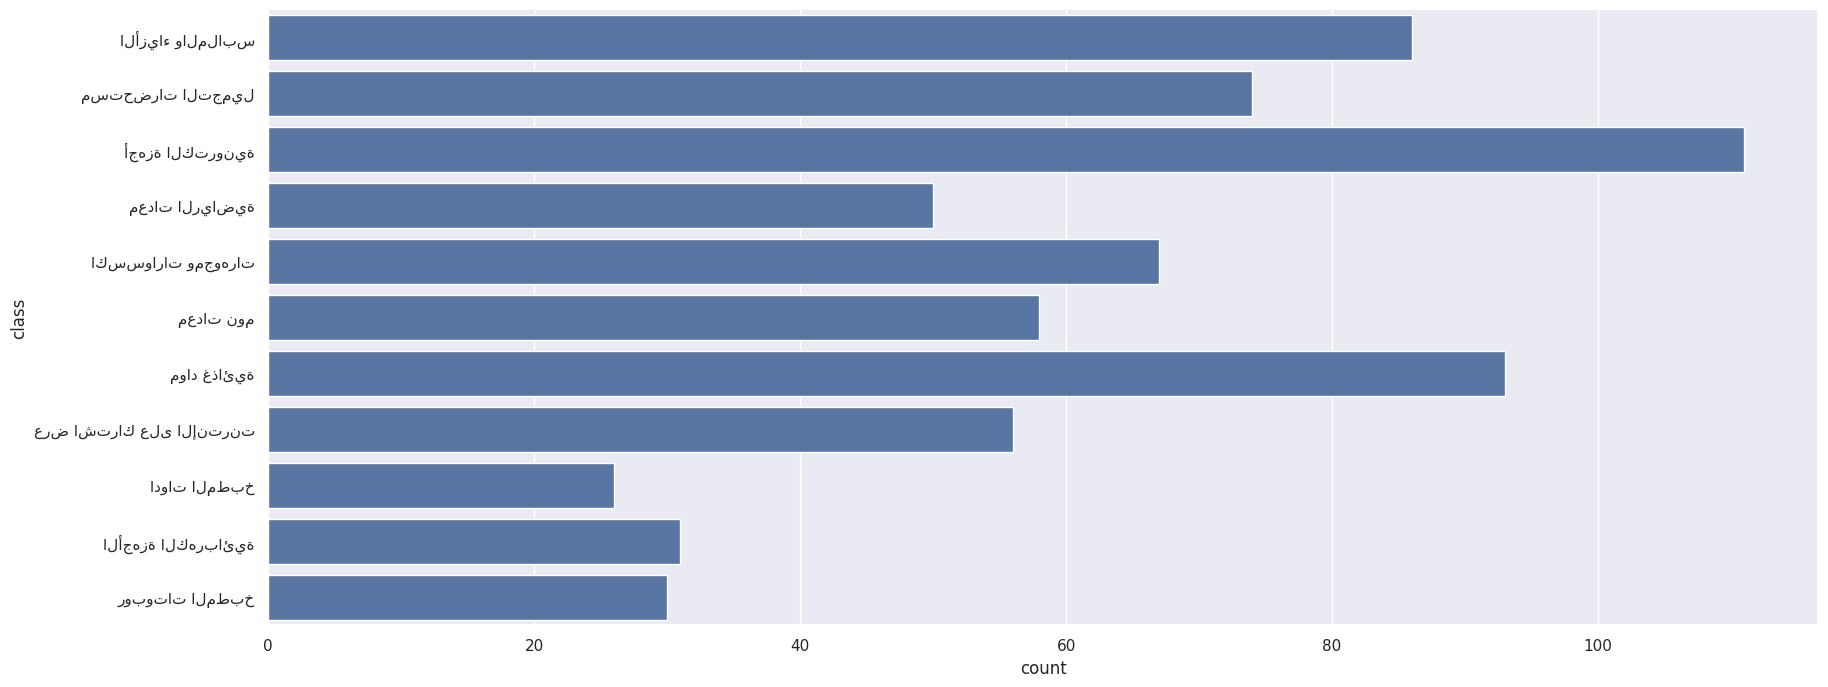

In [ ]:
sns.set(rc = {'figure.figsize':(20,8)})
sns.countplot(posts['class'])

# **TALN- DIALECTE ALGÉRIEN** ✅

## **Prétraitements** Part 1 ✅

### **Suppression des urls:**

In [ ]:
def delete_url(text):
    URLless_string = re.sub(r'\w+:\/{2}[\d\w-]+(\.[\d\w-]+)*(?:(?:\/[^\s/]*))*', '', text)
    return URLless_string

In [ ]:
posts['fp_pretraitements_1']=posts['facebook_posts'].apply(delete_url)

###  **Suppression des ponctuations including 'hashtag' et sauvegarde du mot:**

In [ ]:
def delete_punc_hash(text):
    remove_punct= re.sub(r"[^\w\s]", '', text)
    return remove_punct

In [ ]:
posts['fp_pretraitements_1']=posts['fp_pretraitements_1'].apply(delete_punc_hash)

In [ ]:
posts['fp_pretraitements_1']=posts['fp_pretraitements_1'].str.replace('_',' ')

In [ ]:
posts.head(20)

,facebook_posts,class,fp_pretraitements_1
0,On n'a jamais assez de chaussures 👟 👠 👡 👢 \r\nاليوم كاين تخفيضات على الأحذية 😍 أبروفيتو !! \r\...,الأزياء والملابس,On na jamais assez de chaussures \r\nاليوم كاين تخفيضات على الأحذية أبروفيتو \r\nكي تشرو...
1,7abaa tkoun 3andek une peau rayonnante احسن المنتجات فالماركات لي تحبوهم L'Oréal و حتى Nivea Gar...,مستحضرات التجميل,7abaa tkoun 3andek une peau rayonnante احسن المنتجات فالماركات لي تحبوهم LOréal و حتى Nivea Garnier
2,ثاني واحد بعد ال @ رايح يشريلك Smart TV ماركيه فالكومنتير 😅😅\r\nوزيد قولو بلي كاين Flash Vente ه...,أجهزة الكترونية,ثاني واحد بعد ال رايح يشريلك Smart TV ماركيه فالكومنتير \r\nوزيد قولو بلي كاين Flash Vente هبال...
3,Journée Spéciale Sport 😎🏃‍♀️ \r\nحاب تدير سبور فالدار 🏋️ و ما عندكش Matériel ؟ جوميا تعرض عليك أ...,معدات الرياضية,Journée Spéciale Sport \r\nحاب تدير سبور فالدار و ما عندكش Matériel جوميا تعرض عليك أحسن المس...
4,madame 3andek 3arss w 7aayra wesh diri accessoires??? اضربوا طلة على اختياراتنا في أروج المودي...,اكسسوارات ومجوهرات,madame 3andek 3arss w 7aayra wesh diri accessoires اضربوا طلة على اختياراتنا في أروج الموديلات...
5,kech plan more l3id ?? erwa7 dir bon plan camping m3a s7abek منتجات من وسائد وفراشات الخيام,معدات نوم,kech plan more l3id erwa7 dir bon plan camping m3a s7abek منتجات من وسائد وفراشات الخيام
6,ماكاش أحلى من الشوكولاتة تهديها لحبايبك وعايلتك في أي وقت 🍫🤤 😍\r\nتقدروا تشوفوا كل العروض وتشرو...,مواد غذائية,ماكاش أحلى من الشوكولاتة تهديها لحبايبك وعايلتك في أي وقت \r\nتقدروا تشوفوا كل العروض وتشروا ل...
7,connectez winma 7abit!! M3a Djezzy forfait internet yelha9 partout http://www.ooredoo.dz #Intern...,عرض اشتراك على الإنترنت,connectez winma 7abit M3a Djezzy forfait internet yelha9 partout Internet YouTube Illimité Oore...
8,bedelte 3etba w 5assek t3amer darek !!! Rak f le bon endroit 😍 تقدروا تشوفوا كل العروض مطبخ فالم...,ادوات المطبخ,bedelte 3etba w 5assek t3amer darek Rak f le bon endroit تقدروا تشوفوا كل العروض مطبخ فالمقالي...
9,لكامل محبي L'électroménager Frigo lave-linge Télévision et ordinateur أبروفيتيو هاد السمانة 🔥 😍...,الأجهزة الكهربائية,لكامل محبي Lélectroménager Frigo lavelinge Télévision et ordinateur أبروفيتيو هاد السمانة فوق...


### **Tokenization** ✅

In [ ]:
def tokenize(text):
  tokens = re.split('\W+', text)
  return tokens

<>:2: SyntaxWarning: invalid escape sequence '\W'
<>:2: SyntaxWarning: invalid escape sequence '\W'
/tmp/ipykernel_8040/2568433612.py:2: SyntaxWarning: invalid escape sequence '\W'
  tokens = re.split('\W+', text)


In [ ]:
posts['fp_tokens']=posts['fp_pretraitements_1'].apply(tokenize)

In [ ]:
posts.head(2)

,facebook_posts,class,fp_pretraitements_1,fp_tokens
0,On n'a jamais assez de chaussures 👟 👠 👡 👢 \r\nاليوم كاين تخفيضات على الأحذية 😍 أبروفيتو !! \r\...,الأزياء والملابس,On na jamais assez de chaussures \r\nاليوم كاين تخفيضات على الأحذية أبروفيتو \r\nكي تشرو...,"[On, na, jamais, assez, de, chaussures, اليوم, كاين, تخفيضات, على, الأحذية, أبروفيتو, كي, تشروا,..."
1,7abaa tkoun 3andek une peau rayonnante احسن المنتجات فالماركات لي تحبوهم L'Oréal و حتى Nivea Gar...,مستحضرات التجميل,7abaa tkoun 3andek une peau rayonnante احسن المنتجات فالماركات لي تحبوهم LOréal و حتى Nivea Garnier,"[7abaa, tkoun, 3andek, une, peau, rayonnante, احسن, المنتجات, فالماركات, لي, تحبوهم, LOréal, و, ..."


## **Arabizi** google API ✅

In [ ]:
from googletrans import Translator

In [ ]:
!pip uninstall -y googletrans httpx httpcore
!pip install -U googletrans==4.0.2

Found existing installation: googletrans 4.0.2
Uninstalling googletrans-4.0.2:
  Successfully uninstalled googletrans-4.0.2
Found existing installation: httpx 0.28.1
Uninstalling httpx-0.28.1:
  Successfully uninstalled httpx-0.28.1
Found existing installation: httpcore 1.0.9
Uninstalling httpcore-1.0.9:
  Successfully uninstalled httpcore-1.0.9
  Using cached googletrans-4.0.2-py3-none-any.whl.metadata (10 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
Using cached googletrans-4.0.2-py3-none-any.whl (18 kB)
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
Using cached httpcore-1.0.9-py3-none-any.whl (78 kB)


In [ ]:
from googletrans import Translator

translator = Translator()

In [ ]:
import googletrans

print(googletrans.LANGUAGES)

{'abk': 'abkhaz', 'ace': 'acehnese', 'ach': 'acholi', 'aar': 'afar', 'af': 'afrikaans', 'sq': 'albanian', 'alz': 'alur', 'am': 'amharic', 'ar': 'arabic', 'hy': 'armenian', 'as': 'assamese', 'ava': 'avar', 'awa': 'awadhi', 'ay': 'aymara', 'az': 'azerbaijani', 'ban': 'balinese', 'bal': 'baluchi', 'bm': 'bambara', 'bci': 'baoulé', 'bak': 'bashkir', 'eu': 'basque', 'btx': 'batak karo', 'bts': 'batak simalungun', 'bbc': 'batak toba', 'be': 'belarusian', 'bem': 'bemba', 'bn': 'bengali', 'bew': 'betawi', 'bho': 'bhojpuri', 'bik': 'bikol', 'bs': 'bosnian', 'bre': 'breton', 'bg': 'bulgarian', 'bua': 'buryat', 'yue': 'cantonese', 'ca': 'catalan', 'ceb': 'cebuano', 'cha': 'chamorro', 'che': 'chechen', 'zh': 'chinese', 'zh-cn': 'chinese (simplified)', 'zh-tw': 'chinese (traditional)', 'chk': 'chuukese', 'chv': 'chuvash', 'co': 'corsican', 'crh': 'crimean tatar', 'hr': 'croatian', 'cs': 'czech', 'da': 'danish', 'fa-af': 'dari', 'dv': 'dhivehi', 'din': 'dinka', 'doi': 'dogri', 'dom': 'dombe', 'nl': 

In [ ]:
def translate_arabizi(text):
    list=[]
    translator = Translator()
    tarjama =translator.translate(text,dest='ar')
    for elt in tarjama:
        list.append(elt.text)
    return list

In [ ]:
posts['fp_tokens'].iloc[0]

['On',
 'na',
 'jamais',
 'assez',
 'de',
 'chaussures',
 'اليوم',
 'كاين',
 'تخفيضات',
 'على',
 'الأحذية',
 'أبروفيتو',
 'كي',
 'تشروا',
 'قيس',
 '1000',
 'دج',
 'ولا',
 'كثر',
 'عندكم',
 '500',
 'دج',
 'باطل',
 'كمنديو',
 'من',
 'هنا',
 'معاكم',
 'كل',
 'يوم',
 'جوميا',
 'Jumia',
 'Jumiadz',
 'Festival',
 'des',
 'Marques']

In [ ]:
def translate_arabizi(tokens):
    result = []

    for token in tokens:
        try:
            translated = translator.translate(token, dest='ar')
            result.append(translated.text)
        except Exception:
            result.append(token)

    return result

In [ ]:
posts['fp_tokens_arabizi'] = posts['fp_tokens'].apply(translate_arabizi)

/tmp/ipykernel_8040/861180471.py:6: RuntimeWarning: coroutine 'Translator.translate' was never awaited
  translated = translator.translate(token, dest='ar')
/usr/local/lib/python3.13/dist-packages/pandas/core/algorithms.py:1743: RuntimeWarning: coroutine 'Translator.translate' was never awaited
  return lib.map_infer(values, mapper, convert=convert)


In [ ]:
posts['fp_tokens_arabizi']=posts['fp_tokens'].apply(translate_arabizi)

/tmp/ipykernel_8040/861180471.py:6: RuntimeWarning: coroutine 'Translator.translate' was never awaited
  translated = translator.translate(token, dest='ar')
/usr/local/lib/python3.13/dist-packages/pandas/core/algorithms.py:1743: RuntimeWarning: coroutine 'Translator.translate' was never awaited
  return lib.map_infer(values, mapper, convert=convert)


⏲ **Execution Time: 30 min 53 s** ⏲
For 1000 posts only

In [ ]:
posts[['fp_tokens','fp_tokens_arabizi']].head(1)

,fp_tokens,fp_tokens_arabizi
0,"[On, na, jamais, assez, de, chaussures, اليوم, كاين, تخفيضات, على, الأحذية, أبروفيتو, كي, تشروا,...","[On, na, jamais, assez, de, chaussures, اليوم, كاين, تخفيضات, على, الأحذية, أبروفيتو, كي, تشروا,..."


## **Prétraitements** Part 2 ✅


### **Suppression des Stopwords Arabe + Extended Arabe Algérien**

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
print(nltk.corpus.stopwords.words('arabic'))

['إذ', 'إذا', 'إذما', 'إذن', 'أف', 'أقل', 'أكثر', 'ألا', 'إلا', 'التي', 'الذي', 'الذين', 'اللاتي', 'اللائي', 'اللتان', 'اللتيا', 'اللتين', 'اللذان', 'اللذين', 'اللواتي', 'إلى', 'إليك', 'إليكم', 'إليكما', 'إليكن', 'أم', 'أما', 'أما', 'إما', 'أن', 'إن', 'إنا', 'أنا', 'أنت', 'أنتم', 'أنتما', 'أنتن', 'إنما', 'إنه', 'أنى', 'أنى', 'آه', 'آها', 'أو', 'أولاء', 'أولئك', 'أوه', 'آي', 'أي', 'أيها', 'إي', 'أين', 'أين', 'أينما', 'إيه', 'بخ', 'بس', 'بعد', 'بعض', 'بك', 'بكم', 'بكم', 'بكما', 'بكن', 'بل', 'بلى', 'بما', 'بماذا', 'بمن', 'بنا', 'به', 'بها', 'بهم', 'بهما', 'بهن', 'بي', 'بين', 'بيد', 'تلك', 'تلكم', 'تلكما', 'ته', 'تي', 'تين', 'تينك', 'ثم', 'ثمة', 'حاشا', 'حبذا', 'حتى', 'حيث', 'حيثما', 'حين', 'خلا', 'دون', 'ذا', 'ذات', 'ذاك', 'ذان', 'ذانك', 'ذلك', 'ذلكم', 'ذلكما', 'ذلكن', 'ذه', 'ذو', 'ذوا', 'ذواتا', 'ذواتي', 'ذي', 'ذين', 'ذينك', 'ريث', 'سوف', 'سوى', 'شتان', 'عدا', 'عسى', 'عل', 'على', 'عليك', 'عليه', 'عما', 'عن', 'عند', 'غير', 'فإذا', 'فإن', 'فلا', 'فمن', 'في', 'فيم', 'فيما', 'فيه', 'فيها', '

In [ ]:
new_stopwords=['دايرين','عليكم','ديالكم','الان','راكم','طله','حاجه','كامل','حتي','شهر','مده','وغدوه','الجمعه','كيما','الهم','ماكاش','اي','وقت','تكونو','دايمن','ثاني','واحد','بعد','بلي','اللي','مازال','ما','بيها','دايما','بـ','عند','وهذا','نهار','المزيد','موقعنا','وغدوة','غدوة','إضافي','نهار','لا','تو','تحتها','جدا','السوم','عندنا','بإذن','تكونو','كان','شكون','كي','هاد','فوق','تع','لكامل','هاذ','باش','راهو','بدلا','كي' ,'يوم','قيس','ولا','كثر','عندكم','كل','قابل','أحنا','عندنا','جانفي','فيفري','اليوم','مارس','ديالكم','كاين','باذن','مازالهم','السمانه','عندكش','باطل','تاع','دج','ل','ال','من عند','ا',' أ','راهم','بش', 'تكون','','عندو', 'عندك', 'لى','كاينين','واش','علي','أفريل','ماي','جوان','جويلية','أوت','سبتمبر']
stpwrdextended = nltk.corpus.stopwords.words('arabic')
stpwrdextended.extend(new_stopwords)

In [ ]:
def clean_stopwords(text):
    arabic_DZ_stopwords_free = [words for words in text if words not in stpwrdextended]
    return arabic_DZ_stopwords_free

In [ ]:
posts['fp_tokens_arabizi_cleaned_stopwords_numbers']=posts['fp_tokens_arabizi'].apply(clean_stopwords)

### **Suppression des nombres ar-fr** maintenant possible aprés le traitement de l'Arabizi

In [ ]:
def delete_numbers(location):
    del_numbers = re.sub(r'[0-9]+','', str(location))
    return del_numbers

In [ ]:
def delete_ar_numbers(location):
    del_numbers = re.sub(r'[٠-٩]+','', str(location))
    return del_numbers


In [ ]:
posts['fp_tokens_arabizi_cleaned_stopwords_numbers']=posts['fp_tokens_arabizi_cleaned_stopwords_numbers'].apply(delete_numbers).apply(delete_ar_numbers)

In [ ]:
posts[['fp_tokens_arabizi','fp_tokens_arabizi_cleaned_stopwords_numbers']].head(40)

,fp_tokens_arabizi,fp_tokens_arabizi_cleaned_stopwords_numbers
0,"[On, na, jamais, assez, de, chaussures, اليوم, كاين, تخفيضات, على, الأحذية, أبروفيتو, كي, تشروا,...","['On', 'na', 'jamais', 'assez', 'de', 'chaussures', 'تخفيضات', 'الأحذية', 'أبروفيتو', 'تشروا', '..."
1,"[7abaa, tkoun, 3andek, une, peau, rayonnante, احسن, المنتجات, فالماركات, لي, تحبوهم, LOréal, و, ...","['abaa', 'tkoun', 'andek', 'une', 'peau', 'rayonnante', 'احسن', 'المنتجات', 'فالماركات', 'تحبوهم..."
2,"[ثاني, واحد, بعد, ال, رايح, يشريلك, Smart, TV, ماركيه, فالكومنتير, وزيد, قولو, بلي, كاين, Flash,...","['رايح', 'يشريلك', 'Smart', 'TV', 'ماركيه', 'فالكومنتير', 'وزيد', 'قولو', 'Flash', 'Vente', 'هبا..."
3,"[Journée, Spéciale, Sport, حاب, تدير, سبور, فالدار, و, ما, عندكش, Matériel, جوميا, تعرض, عليك, أ...","['Journée', 'Spéciale', 'Sport', 'حاب', 'تدير', 'سبور', 'فالدار', 'Matériel', 'جوميا', 'تعرض', '..."
4,"[madame, 3andek, 3arss, w, 7aayra, wesh, diri, accessoires, اضربوا, طلة, على, اختياراتنا, في, أر...","['madame', 'andek', 'arss', 'w', 'aayra', 'wesh', 'diri', 'accessoires', 'اضربوا', 'طلة', 'اختيا..."
5,"[kech, plan, more, l3id, erwa7, dir, bon, plan, camping, m3a, s7abek, منتجات, من, وسائد, وفراشات...","['kech', 'plan', 'more', 'lid', 'erwa', 'dir', 'bon', 'plan', 'camping', 'ma', 'sabek', 'منتجات'..."
6,"[ماكاش, أحلى, من, الشوكولاتة, تهديها, لحبايبك, وعايلتك, في, أي, وقت, تقدروا, تشوفوا, كل, العروض,...","['أحلى', 'الشوكولاتة', 'تهديها', 'لحبايبك', 'وعايلتك', 'تقدروا', 'تشوفوا', 'العروض', 'وتشروا', '..."
7,"[connectez, winma, 7abit, M3a, Djezzy, forfait, internet, yelha9, partout, Internet, YouTube, Il...","['connectez', 'winma', 'abit', 'Ma', 'Djezzy', 'forfait', 'internet', 'yelha', 'partout', 'Inter..."
8,"[bedelte, 3etba, w, 5assek, t3amer, darek, Rak, f, le, bon, endroit, تقدروا, تشوفوا, كل, العروض,...","['bedelte', 'etba', 'w', 'assek', 'tamer', 'darek', 'Rak', 'f', 'le', 'bon', 'endroit', 'تقدروا'..."
9,"[لكامل, محبي, Lélectroménager, Frigo, lavelinge, Télévision, et, ordinateur, أبروفيتيو, هاد, الس...","['محبي', 'Lélectroménager', 'Frigo', 'lavelinge', 'Télévision', 'et', 'ordinateur', 'أبروفيتيو',..."


### **Nomralisation de l'alphabet arabe PyArabic**✅

In [ ]:
#posts = posts.drop(columns="posts_dialecte_algérien")

In [ ]:
def untokenize(text):
    step1 = text.replace("[", '').replace("]", '').replace("'", '').replace('"',  '').replace(","," ")
    return step1

In [ ]:
posts['fp_pyarabic']=posts['fp_tokens_arabizi_cleaned_stopwords_numbers'].apply(untokenize)

In [ ]:
pip install pyarabic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 5.0 MB/s eta 0:00:00


In [ ]:
#from os import listdir
#from os.path import isfile, join
from pyarabic import araby

In [ ]:
def process(text):
	text = araby.strip_tashkeel(text) #suppression de voyellation si existante
	#text = text.lower()
	text = re.sub('\ـ+', ' ', text)  # delete letter madda

	text = re.sub('\ر+', 'ر', text)  # duplicate ra2
	text = re.sub('\اا+','ا',text)     #duplicate alif
	text = re.sub('\ووو+','و',text)   #duplicate waw
	text = re.sub('\ههه+','ه',text)
	text = re.sub('\ةة+','ة',text)
	text = re.sub('\ييي+','ي',text)

	text = re.sub('؟','',text)
	text = re.sub('أ','ا',text)
	text = re.sub('إ','ا',text)
	text = re.sub('ة','ه',text)
	#text = re.sub('ي','ى',text)


	text = " ".join(text.split()) #delete multispace

	return text

In [ ]:
posts['fp_pyarabic']=posts['fp_pyarabic'].apply(process)

In [ ]:
posts['keywords_posts_dialecte_algérien']=posts['fp_pyarabic'].apply(tokenize)

In [ ]:
posts.head(2)

,facebook_posts,class,fp_pretraitements_1,fp_tokens,fp_tokens_arabizi,fp_tokens_arabizi_cleaned_stopwords_numbers,fp_pyarabic,keywords_posts_dialecte_algérien
0,On n'a jamais assez de chaussures 👟 👠 👡 👢 \r\nاليوم كاين تخفيضات على الأحذية 😍 أبروفيتو !! \r\...,الأزياء والملابس,On na jamais assez de chaussures \r\nاليوم كاين تخفيضات على الأحذية أبروفيتو \r\nكي تشرو...,"[On, na, jamais, assez, de, chaussures, اليوم, كاين, تخفيضات, على, الأحذية, أبروفيتو, كي, تشروا,...","[On, na, jamais, assez, de, chaussures, اليوم, كاين, تخفيضات, على, الأحذية, أبروفيتو, كي, تشروا,...","['On', 'na', 'jamais', 'assez', 'de', 'chaussures', 'تخفيضات', 'الأحذية', 'أبروفيتو', 'تشروا', '...",On na jamais assez de chaussures تخفيضات الاحذيه ابروفيتو تشروا كمنديو معاكم جوميا Jumia Jumiadz...,"[On, na, jamais, assez, de, chaussures, تخفيضات, الاحذيه, ابروفيتو, تشروا, كمنديو, معاكم, جوميا,..."
1,7abaa tkoun 3andek une peau rayonnante احسن المنتجات فالماركات لي تحبوهم L'Oréal و حتى Nivea Gar...,مستحضرات التجميل,7abaa tkoun 3andek une peau rayonnante احسن المنتجات فالماركات لي تحبوهم LOréal و حتى Nivea Garnier,"[7abaa, tkoun, 3andek, une, peau, rayonnante, احسن, المنتجات, فالماركات, لي, تحبوهم, LOréal, و, ...","[7abaa, tkoun, 3andek, une, peau, rayonnante, احسن, المنتجات, فالماركات, لي, تحبوهم, LOréal, و, ...","['abaa', 'tkoun', 'andek', 'une', 'peau', 'rayonnante', 'احسن', 'المنتجات', 'فالماركات', 'تحبوهم...",abaa tkoun andek une peau rayonnante احسن المنتجات فالماركات تحبوهم LOréal Nivea Garnier,"[abaa, tkoun, andek, une, peau, rayonnante, احسن, المنتجات, فالماركات, تحبوهم, LOréal, Nivea, Ga..."


### **Pos-Tag Manually** ✅

In [ ]:
adj=['كبيره','احسن','التابع','هبال','جيد','جميل','كبير','قبيح','عيان','فرحان','زعفان','كاره','منيرفي','مخلوع','دهشان','احسن','التابع','هبال','جيد','جميل','كبير','قبيح','عيان','فرحان','زعفان','كاره','منيرفي','مخلوع','دهشان']

In [ ]:
def delete_adj(text):
    arabic_DZ_adj_free = [words for words in text if words not in adj]
    return arabic_DZ_adj_free

In [ ]:
posts['keywords_posts_dialecte_algérien']=posts['keywords_posts_dialecte_algérien'].apply(delete_adj)

In [ ]:
posts[['keywords_posts_dialecte_algérien','class']].head(11)

,keywords_posts_dialecte_algérien,class
0,"[On, na, jamais, assez, de, chaussures, تخفيضات, الاحذيه, ابروفيتو, تشروا, كمنديو, معاكم, جوميا,...",الأزياء والملابس
1,"[abaa, tkoun, andek, une, peau, rayonnante, المنتجات, فالماركات, تحبوهم, LOréal, Nivea, Garnier]",مستحضرات التجميل
2,"[رايح, يشريلك, Smart, TV, ماركيه, فالكومنتير, وزيد, قولو, Flash, Vente, الاجهزه, الالكترونيه, تط...",أجهزة الكترونية
3,"[Journée, Spéciale, Sport, حاب, تدير, سبور, فالدار, Matériel, جوميا, تعرض, المستلزمات, باسعار, غ...",معدات الرياضية
4,"[madame, andek, arss, w, aayra, wesh, diri, accessoires, اضربوا, طله, اختياراتنا, اروج, الموديلا...",اكسسوارات ومجوهرات
5,"[kech, plan, more, lid, erwa, dir, bon, plan, camping, ma, sabek, منتجات, وسائد, وفراشات, الخيام]",معدات نوم
6,"[احلى, الشوكولاته, تهديها, لحبايبك, وعايلتك, تقدروا, تشوفوا, العروض, وتشروا, لاحلى, حبايبكم, réd...",مواد غذائية
7,"[connectez, winma, abit, Ma, Djezzy, forfait, internet, yelha, partout, Internet, YouTube, Illim...",عرض اشتراك على الإنترنت
8,"[bedelte, etba, w, assek, tamer, darek, Rak, f, le, bon, endroit, تقدروا, تشوفوا, العروض, مطبخ, ...",ادوات المطبخ
9,"[محبي, Lélectroménager, Frigo, lavelinge, Télévision, et, ordinateur, ابروفيتيو, السمانه, العروض...",الأجهزة الكهربائية


# **APPROCHE PROPOSÉE**

## **Train & Test** ✅

In [ ]:
def multispaces(text):
    removeSpaces = re.sub('\\s+', ' ', text)
    return removeSpaces

In [ ]:
#Stocker les textes dans la variable "texts"
texts= posts['keywords_posts_dialecte_algérien']

#Stocker les classes dans la variable "tags"
tags = posts['class']

In [ ]:
train_size = int(len(posts) * .8)
print(int(len(posts['keywords_posts_dialecte_algérien'])))
print(train_size)

682
545


In [ ]:
train_posts = posts['keywords_posts_dialecte_algérien'][:train_size]
train_tags = posts['class'][:train_size]

test_posts = posts['keywords_posts_dialecte_algérien'][train_size:]
test_tags =  posts['class'][train_size:]

## **Vectorisation Tf-Idf**✅

In [ ]:
#from Text to Matrix using Tokenizer
tokenizer = Tokenizer(num_words=None,lower=False)
tokenizer.fit_on_texts(texts)

In [ ]:
x_train = tokenizer.texts_to_matrix(train_posts, mode='tfidf')
x_test = tokenizer.texts_to_matrix(test_posts, mode='tfidf')

In [ ]:
print(" x_train:",x_train.shape,"\n","x_test:",x_test.shape)

 x_train: (545, 511) 
 x_test: (137, 511)


In [ ]:
x_train

array([[0.        , 1.20226486, 0.95877173, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 2.03561136, 0.95877173, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.95877173, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

## **Sauvegarde et Chargement**

In [ ]:
import pickle

# saving
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

# loading
with open('tokenizer.pickle', 'rb') as handle:
    tokenizer = pickle.load(handle)

## **Labels Encoding** La représentation des classes par des numeros uniques ✅

In [ ]:
encoder = LabelEncoder()
encoder.fit(tags)
tagst=encoder.fit_transform(tags)
print(tagst)

[ 5  8  1  9  3  0 10  7  2  4  6  5  8  6  1  9  3  0 10 10  7  2  4  1
  6  6  6  5  1  6 10 10  6  6 10 10 10 10  6  6  1  1  5  5  3  5  5  5
  3  5  5  5  3  5  5  5  3  8  0  0  9  1  3  8  1  1  1  1  8  0 10  3
  3  1  3  1  3  3 10 10 10 10 10 10  1  1  3  9 10  8  1  1 10 10 10 10
 10 10  1  1  7  7  7  1  5 10  5  2  9  4  5  6  8 10  5  5 10  8  9  1
  3  8  8  0 10  9 10  8  1  1  7  7  7  1  5 10  5  2  9  4  5  6  8 10
  5  5 10  8  9  1  3  3  8  8  0 10  9 10  8  1  1  7  7  7  1  5 10  5
  2  9  4  5  6  8 10  5  5 10  8  9  1  3  8  8  0 10  9 10  8  1  1  7
  7  7  1  5 10  5  2  9  4  5  6  8 10  5  5 10  8  9  1  3  8  8  0 10
  9 10  8  1  1  7  7  7  1  5 10  5  2  9  4  5  6  8 10  5  5 10  8  9
  1  3  8  8  0 10  9 10  8  1  1  7  7  7  1  5 10  5  2  9  4  5  6  8
 10  5  5 10  8  9  1  3  8  8  0 10  4  4  4  4  4  4  4  4  4  9 10  8
  1  1  7  7  7  1  5 10  5  2  9  4  5  6  8 10  5  5 10  8  9  1  3  8
  8  0 10  9 10  8  1  1  7  7  7  1  5 10  5  2  9

In [ ]:
num_classes = int((len(set(tagst))))
print((len(set(tagst))))

y_train = encoder.fit_transform(train_tags)
y_test = encoder.fit_transform(test_tags)

11


In [ ]:
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

num_labels = int(len(y_train.shape))

vocab_size = len(tokenizer.word_index) + 1

max_words=vocab_size

In [ ]:
vocab_size = len(tokenizer.word_index) + 1
vocab_size

511

In [ ]:
max_words

511

**La taille du vocabulaire dans le modéle Tokenizer : 380** 📖

In [ ]:
vocab_size

474

## **Les métriques d'évaluations**✅

In [ ]:
from keras.metrics import Precision , Recall , Accuracy , TruePositives , TrueNegatives , FalsePositives , FalseNegatives

## **Construction du modèle**

In [ ]:
le_modele = Sequential()

#layer1
le_modele.add(Dense(2000, input_shape=(max_words,))),
le_modele.add(Activation('relu')),

le_modele.add(Dropout(0.4)),

#layer2
le_modele.add(Dense(num_classes)),
le_modele.add(Activation('sigmoid'))

#le_modele.add(Activation('softmax'))  #NO WAY evaluation tres mauvaise!

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from tensorflow.keras.utils import plot_model

In [ ]:
le_modele.compile(loss ='categorical_crossentropy',optimizer='adam',metrics=['categorical_accuracy','Recall','Precision','Accuracy'])
#le_modele1.compile(optimizer='adam',loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['categorical_accuracy','Recall','Precision'])

In [ ]:
history = le_modele.fit(x_train, y_train, batch_size=100, epochs=2, verbose=1, validation_split=0.1)

le_modele.save('le_model.keras')

Epoch 1/2
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - Accuracy: 1.0000 - Precision: 0.4020 - Recall: 1.0000 - categorical_accuracy: 1.0000 - loss: 0.0116 - val_Accuracy: 1.0000 - val_Precision: 0.5000 - val_Recall: 1.0000 - val_categorical_accuracy: 1.0000 - val_loss: 0.0055
Epoch 2/2
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - Accuracy: 1.0000 - Precision: 0.4537 - Recall: 1.0000 - categorical_accuracy: 1.0000 - loss: 0.0027 - val_Accuracy: 1.0000 - val_Precision: 0.5851 - val_Recall: 1.0000 - val_categorical_accuracy: 1.0000 - val_loss: 0.0017


## **Évaluation**

In [ ]:
#the_model = keras.models.load_model('my_model.h')
Evaluation = le_modele.evaluate(x_test,y_test,verbose=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - Accuracy: 1.0000 - Precision: 0.6850 - Recall: 1.0000 - categorical_accuracy: 1.0000 - loss: 0.0017


`5  9  2  3  0  4  8  6  7  1 10`

In [ ]:
for x in posts["keywords_posts_dialecte_algérien"][:11]:

    tokens = tokenizer.texts_to_matrix([x], mode='tfidf')

    c=le_modele.predict(np.array(tokens))
    cc=np.argmax(c,axis=1)
    #xc = encoder.inverse_transform(cc)

    print(c,"=\t",cc,"\t")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
[[0.07830304 0.35371464 0.10642213 0.10511143 0.0279079  0.99991274
  0.18034498 0.14799228 0.5507963  0.10992891 0.33403805]] =	 [5] 	
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[0.12672672 0.5167976  0.07847379 0.15155809 0.08922715 0.59624887
  0.13561426 0.18607631 0.9996708  0.28649467 0.36839798]] =	 [8] 	
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.05478105 0.99998796 0.03694749 0.09448353 0.05894234 0.2788764
  0.09910122 0.11981846 0.41326806 0.2302811  0.5043112 ]] =	 [1] 	
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[0.13977335 0.42218328 0.03714478 0.1530317  0.05258606 0.44458237
  0.13515043 0.2522916  0.35673943 0.9996095  0.5120554 ]] =	 [9] 	
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.07323887 0.07170568 0.00408699 0.9999993  0.01730746 0.5868377
  0.04965875 0.09361766 0.2742553  0.03911051 0.49703065]] =	 [3] 	
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
[[0.9998583  0.21937536 0.05646602 0.18233737 0.04669548 0.5135409
  0.0841453  0.11479338 0.3

In [ ]:
posts.head(10)

,facebook_posts,class,fp_pretraitements_1,fp_tokens,fp_tokens_arabizi,fp_tokens_arabizi_cleaned_stopwords_numbers,fp_pyarabic,keywords_posts_dialecte_algérien
0,On n'a jamais assez de chaussures 👟 👠 👡 👢 \r\nاليوم كاين تخفيضات على الأحذية 😍 أبروفيتو !! \r\...,الأزياء والملابس,On na jamais assez de chaussures \r\nاليوم كاين تخفيضات على الأحذية أبروفيتو \r\nكي تشرو...,"[On, na, jamais, assez, de, chaussures, اليوم, كاين, تخفيضات, على, الأحذية, أبروفيتو, كي, تشروا,...","[On, na, jamais, assez, de, chaussures, اليوم, كاين, تخفيضات, على, الأحذية, أبروفيتو, كي, تشروا,...","['On', 'na', 'jamais', 'assez', 'de', 'chaussures', 'تخفيضات', 'الأحذية', 'أبروفيتو', 'تشروا', '...",On na jamais assez de chaussures تخفيضات الاحذيه ابروفيتو تشروا كمنديو معاكم جوميا Jumia Jumiadz...,"[On, na, jamais, assez, de, chaussures, تخفيضات, الاحذيه, ابروفيتو, تشروا, كمنديو, معاكم, جوميا,..."
1,7abaa tkoun 3andek une peau rayonnante احسن المنتجات فالماركات لي تحبوهم L'Oréal و حتى Nivea Gar...,مستحضرات التجميل,7abaa tkoun 3andek une peau rayonnante احسن المنتجات فالماركات لي تحبوهم LOréal و حتى Nivea Garnier,"[7abaa, tkoun, 3andek, une, peau, rayonnante, احسن, المنتجات, فالماركات, لي, تحبوهم, LOréal, و, ...","[7abaa, tkoun, 3andek, une, peau, rayonnante, احسن, المنتجات, فالماركات, لي, تحبوهم, LOréal, و, ...","['abaa', 'tkoun', 'andek', 'une', 'peau', 'rayonnante', 'احسن', 'المنتجات', 'فالماركات', 'تحبوهم...",abaa tkoun andek une peau rayonnante احسن المنتجات فالماركات تحبوهم LOréal Nivea Garnier,"[abaa, tkoun, andek, une, peau, rayonnante, المنتجات, فالماركات, تحبوهم, LOréal, Nivea, Garnier]"
2,ثاني واحد بعد ال @ رايح يشريلك Smart TV ماركيه فالكومنتير 😅😅\r\nوزيد قولو بلي كاين Flash Vente ه...,أجهزة الكترونية,ثاني واحد بعد ال رايح يشريلك Smart TV ماركيه فالكومنتير \r\nوزيد قولو بلي كاين Flash Vente هبال...,"[ثاني, واحد, بعد, ال, رايح, يشريلك, Smart, TV, ماركيه, فالكومنتير, وزيد, قولو, بلي, كاين, Flash,...","[ثاني, واحد, بعد, ال, رايح, يشريلك, Smart, TV, ماركيه, فالكومنتير, وزيد, قولو, بلي, كاين, Flash,...","['رايح', 'يشريلك', 'Smart', 'TV', 'ماركيه', 'فالكومنتير', 'وزيد', 'قولو', 'Flash', 'Vente', 'هبا...",رايح يشريلك Smart TV ماركيه فالكومنتير وزيد قولو Flash Vente هبال الاجهزه الالكترونيه تطبيق جومي...,"[رايح, يشريلك, Smart, TV, ماركيه, فالكومنتير, وزيد, قولو, Flash, Vente, الاجهزه, الالكترونيه, تط..."
3,Journée Spéciale Sport 😎🏃‍♀️ \r\nحاب تدير سبور فالدار 🏋️ و ما عندكش Matériel ؟ جوميا تعرض عليك أ...,معدات الرياضية,Journée Spéciale Sport \r\nحاب تدير سبور فالدار و ما عندكش Matériel جوميا تعرض عليك أحسن المس...,"[Journée, Spéciale, Sport, حاب, تدير, سبور, فالدار, و, ما, عندكش, Matériel, جوميا, تعرض, عليك, أ...","[Journée, Spéciale, Sport, حاب, تدير, سبور, فالدار, و, ما, عندكش, Matériel, جوميا, تعرض, عليك, أ...","['Journée', 'Spéciale', 'Sport', 'حاب', 'تدير', 'سبور', 'فالدار', 'Matériel', 'جوميا', 'تعرض', '...",Journée Spéciale Sport حاب تدير سبور فالدار Matériel جوميا تعرض احسن المستلزمات باسعار هبال غيرا...,"[Journée, Spéciale, Sport, حاب, تدير, سبور, فالدار, Matériel, جوميا, تعرض, المستلزمات, باسعار, غ..."
4,madame 3andek 3arss w 7aayra wesh diri accessoires??? اضربوا طلة على اختياراتنا في أروج المودي...,اكسسوارات ومجوهرات,madame 3andek 3arss w 7aayra wesh diri accessoires اضربوا طلة على اختياراتنا في أروج الموديلات...,"[madame, 3andek, 3arss, w, 7aayra, wesh, diri, accessoires, اضربوا, طلة, على, اختياراتنا, في, أر...","[madame, 3andek, 3arss, w, 7aayra, wesh, diri, accessoires, اضربوا, طلة, على, اختياراتنا, في, أر...","['madame', 'andek', 'arss', 'w', 'aayra', 'wesh', 'diri', 'accessoires', 'اضربوا', 'طلة', 'اختيا...",madame andek arss w aayra wesh diri accessoires اضربوا طله اختياراتنا اروج الموديلات خواتم سلاسل...,"[madame, andek, arss, w, aayra, wesh, diri, accessoires, اضربوا, طله, اختياراتنا, اروج, الموديلا..."
5,kech plan more l3id ?? erwa7 dir bon plan camping m3a s7abek منتجات من وسائد وفراشات الخيام,معدات نوم,kech plan more l3id erwa7 dir bon plan camping m3a s7abek منتجات من وسائد وفراشات الخيام,"[kech, plan, more, l3id, erwa7, dir, bon, pla

# **UTILISATION DU MODÉLE:** ⚡

```
mode et vetement 5  
produits cosmétiques 9  
appareils électroniques 2  
articles de sport 3  
accessoires et bijoux 0  
matériel de couchage 4  
produits alimentaires 8  
offre abonnement internet 6  
outils de cuisine 7  
appareils électriques 1
robots de cuisine 10
```



### **TALN 🔤**

In [ ]:
the_input='bech tkoun 3andek une belle peau احسن المنتجات فالماركات لي تحبوهم makeup addict 300  ٩٩٩٩ Nivea Garnier https://deals.dz.jumia.com/alger-city 🎉🎉🎉 !!!! #jumia #peau #makeup '
#the_input='أبروفيتوا اليوم بعروض من وسائد وفراشات.. 😍🔥 en promo d
#the_input="marakch 7ab tayeb f'dar ?? wach 7aab takl lyoum ? tacos et pizzas mane3and Jumia Food dayra promo ta3 hbaal https://deals.dz.jumia.com/alger-city 🎉🎉🎉 #tacos #pizzas"
#the_input="cette phrase sera tokenisée"
the_input_url= delete_url(the_input)
print(the_input_url)

bech tkoun 3andek une belle peau احسن المنتجات فالماركات لي تحبوهم makeup addict 300  ٩٩٩٩ Nivea Garnier  🎉🎉🎉 !!!! #jumia #peau #makeup 


In [ ]:
the_input_punc_hash= delete_punc_hash(the_input_url)
print(the_input_punc_hash)

bech tkoun 3andek une belle peau احسن المنتجات فالماركات لي تحبوهم makeup addict 300  ٩٩٩٩ Nivea Garnier    jumia peau makeup 


In [ ]:
the_input_tokenize= tokenize(the_input_punc_hash)
print(the_input_tokenize)

['bech', 'tkoun', '3andek', 'une', 'belle', 'peau', 'احسن', 'المنتجات', 'فالماركات', 'لي', 'تحبوهم', 'makeup', 'addict', '300', '٩٩٩٩', 'Nivea', 'Garnier', 'jumia', 'peau', 'makeup', '']


In [ ]:
the_input_no_arabizi = translate_arabizi(the_input_tokenize)
print(the_input_no_arabizi)

['bech', 'tkoun', '3andek', 'une', 'belle', 'peau', 'احسن', 'المنتجات', 'فالماركات', 'لي', 'تحبوهم', 'makeup', 'addict', '300', '٩٩٩٩', 'Nivea', 'Garnier', 'jumia', 'peau', 'makeup', '']


/tmp/ipykernel_8040/861180471.py:6: RuntimeWarning: coroutine 'Translator.translate' was never awaited
  translated = translator.translate(token, dest='ar')
/tmp/ipykernel_8040/954695608.py:1: RuntimeWarning: coroutine 'Translator.translate' was never awaited
  the_input_no_arabizi = translate_arabizi(the_input_tokenize)


In [ ]:
the_input_no_sopwords= clean_stopwords(the_input_no_arabizi)
print(the_input_no_sopwords)

['bech', 'tkoun', '3andek', 'une', 'belle', 'peau', 'احسن', 'المنتجات', 'فالماركات', 'تحبوهم', 'makeup', 'addict', '300', '٩٩٩٩', 'Nivea', 'Garnier', 'jumia', 'peau', 'makeup']


In [ ]:
the_input_no_numbers= delete_ar_numbers(the_input_no_sopwords)
print(the_input_no_numbers)

['bech', 'tkoun', '3andek', 'une', 'belle', 'peau', 'احسن', 'المنتجات', 'فالماركات', 'تحبوهم', 'makeup', 'addict', '300', '', 'Nivea', 'Garnier', 'jumia', 'peau', 'makeup']


In [ ]:
the_input_pyarabic= untokenize(the_input_no_numbers)
the_input_pyarabic= process(the_input_pyarabic)
the_input_pyarabic= tokenize(the_input_pyarabic)
print(the_input_pyarabic)

['bech', 'tkoun', '3andek', 'une', 'belle', 'peau', 'احسن', 'المنتجات', 'فالماركات', 'تحبوهم', 'makeup', 'addict', '300', 'Nivea', 'Garnier', 'jumia', 'peau', 'makeup']


In [ ]:
the_input_final= delete_adj(the_input_pyarabic)
print(the_input_final)

['bech', 'tkoun', '3andek', 'une', 'belle', 'peau', 'المنتجات', 'فالماركات', 'تحبوهم', 'makeup', 'addict', '300', 'Nivea', 'Garnier', 'jumia', 'peau', 'makeup']


### **Le Modéle 🌩**

In [ ]:
print(type(input2))
print(np.array(input2).shape)
print(np.array(input2).dtype)

<class 'numpy.ndarray'>
(1, 511)
float64


In [ ]:
input2 = tokenizer.texts_to_matrix([the_input_final], mode='tfidf')

metrics = le_modele.predict(np.array(input2))
category=np.argmax(metrics,axis=1)
print(metrics,"=",category)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
[[0.18468289 0.5425197  0.08869693 0.20477356 0.10670007 0.661357
  0.19615337 0.22420114 0.9956382  0.31175724 0.37187698]] = [8]
